In [1]:
import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
from arch import arch_model
from arch.univariate import ARX
import scipy
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from scipy.stats import kurtosis, skew
from scipy.optimize import minimize

In [2]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [3]:
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_5872/234630771.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_5872/234630771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_5872/234630771.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [4]:
from __future__ import annotations
from arch.univariate.distribution import Distribution
from abc import ABCMeta, abstractmethod
from collections.abc import Sequence
from typing import Callable
import warnings

from numpy import (
    abs,    array,    asarray,    empty,    exp,    int64,    
    integer,    isscalar,    log,    nan,    ndarray, exp,
    ones_like,    pi,    sign,    sqrt,    sum, random)
from numpy.random import Generator, RandomState, default_rng
from scipy.special import comb, gamma, gammainc, gammaincc, gammaln
import scipy.stats as stats
from scipy.optimize import bisect

from arch.typing import ArrayLike, ArrayLike1D, Float64Array
from arch.utility.array import AbstractDocStringInheritor, ensure1d

class MixNormal(Distribution, metaclass=AbstractDocStringInheritor):
    """
    Mixture of two Normal distributions for use with SPARCH model

    Parameters
    ----------
    random_state : RandomState, optional
        .. deprecated:: 5.0

           random_state is deprecated. Use seed instead.

    seed : {int, Generator, RandomState}, optional
        Random number generator instance or int to use. Set to ensure
        reproducibility. If using an int, the argument is passed to
        ``np.random.default_rng``.  If not provided, ``default_rng``
        is used with system-provided entropy.
    """

    def __init__(
        self,
        random_state: RandomState | None = None,
        *,
        seed: None | int | RandomState | Generator = None,
    ) -> None:
        super().__init__(random_state=random_state, seed=seed)
        self._name = "Mixture of two Normal distributions"
        self.num_params: int = 3  

    def constraints(self) -> tuple[Float64Array, Float64Array]:
        return empty(0), empty(0)
        #return array([[1, 0, 0], [-1, 0, 0], [0, 1,0], [0, -1,0] , [0,0,1],[0,0,-1]]), array([0.05, 0.95, -20,20,0.2, 10])

    def bounds(self, resids: Float64Array) -> list[tuple[float, float]]:
        """
        Bounds of parameters:
        p1: (0,1)
        u1: (-10,10)
        sigma_1:(0.001,10)
        """
        return [(0.0001, 0.9999),(-10000,10000),(0.0001, 10000)]

    def loglikelihood(
        self,
        parameters: Sequence[float] | ArrayLike1D,
        resids: ArrayLike,
        sigma2: ArrayLike,
        individual: bool = False,
    ) -> float | Float64Array:
        r"""Computes the log-likelihood of assuming residuals are mixture normally
        distributed, conditional on the variance

        Parameters
        ----------
        parameters : ndarray
            Parameters of the first normal distribution: p1,u1,sigma1. Second one can be calculated by restrictions.
        resids  : ndarray
            The residuals to use in the log-likelihood calculation
        sigma2 : ndarray
            Conditional variances of resids
        individual : bool, optional
            Flag indicating whether to return the vector of individual log
            likelihoods (True) or the sum (False)

        Returns
        -------
        ll : float
            The log-likelihood

        Notes
        -----
        The log-likelihood of a single data point x is

        .. math::

            \ln f\left(x\right)=
            \ln \frac{1}{\sqrt{h_t}} \left[
                 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(x-\mu_1)^2}{2\sigma_1^2} \}
                +(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(x-\mu_2)^2}{2\sigma_2^2} \} \right]

        """
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        z = resids/sqrt(sigma2)
        warnings.filterwarnings("ignore")
        lls =-1/2 *log(sigma2) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2)) 
                                     +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
        warnings.filterwarnings("default")
          
        if individual:
            return lls
        else:
            return sum(lls)

    def starting_values(self, std_resid: Float64Array) -> Float64Array:
        """
        Starting values of parameters
        """
        #gmm = GaussianMixture(n_components=2).fit(std_resid.reshape(-1,1))
        #return array([gmm.weights_[0],gmm.means_[0][0], gmm.covariances_[0][0][0] ])
        return array([0.3, 0.1,1])
    
    def _simulator(self, size: int | tuple[int, ...]) -> Float64Array:
        assert self._parameters is not None
        p1, u1, sigma_1_2 = self._parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        Z = np.random.binomial(n=1, p=p1, size=size)
        return sqrt(sigma_1_2)**Z*sqrt(sigma_2_2)**(1-Z)*self._generator.standard_normal(size) + u1*Z+ u2*(1-Z)

    def simulate(
        self, parameters: int | float | Sequence[float | int] | ArrayLike1D
    ) -> Callable[[int | tuple[int, ...]], Float64Array]:
        parameters = ensure1d(parameters, "parameters", False)
        self._parameters = asarray(parameters, dtype=float)
        return self._simulator

    def parameter_names(self) -> list[str]:
        return ['p_1','mu_1','sigma_1^2']

    def cdf(
        self,
        resids: Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        return p1*stats.norm.cdf(asarray((resids-u1)/sqrt(sigma_1_2))  ) + p2*stats.norm.cdf(asarray((resids-u2)/sqrt(sigma_2_2)))

    def ppf(
        self,
        pits: float | Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        scalar = isscalar(pits)
        if scalar:
            pits = array([pits])
        else:
            pits = asarray(pits)
            
        def inverse_cdf(cdf, target_p, lower_bound=-100, upper_bound=100):
            def root_func(x):
                return cdf(x,parameters) - target_p
            return bisect(root_func, lower_bound, upper_bound)     
        
        ppf = inverse_cdf(self.cdf, pits, lower_bound=-100, upper_bound=100)

        if scalar:
            return ppf[0]
        else:
            return ppf

    def moment(
        self, n: int, parameters: None | Sequence[float] | ArrayLike1D = None
    ) -> float:
        if n < 0:
            return nan
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        moment1 = stats.norm.moment(n,loc=u1,scale=sqrt(sigma_1_2))
        moment2 = stats.norm.moment(n,loc=u2,scale=sqrt(sigma_2_2))
        return p1 * moment1 + p2 * moment2

    def partial_moment(
        self,
        n: int,
        z: float = 0.0,
        parameters: None | Sequence[float] | ArrayLike1D = None,
        num_samples=1000,
    ) -> float:
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        if n < 0:
            return nan
        elif n == 0:
            return cdf(z,parameters)
        elif n==1:
            return -p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))  -p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))
        else:
            -(z ** (n - 1)) * (p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))+p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))) 
            + (n - 1) * self.partial_moment(  n - 2, z, parameters  )

In [5]:
def print_param(params):
    """print distributional parameters"""
    p1,u1,sigma_1_2 = params
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
    print('Mixture of 2 normals parameters: ')
    print("Probabilities: ", [p1,p2])
    print("Means: ", [u1,u2])
    print("Variances: ", [sigma_1_2,sigma_2_2])

In [6]:
def MofN_estimation(errors,volatility):
    z = errors / volatility
    def MofN_llf(params):
        p1,u1,sigma_1_2 = params
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        lls =-np.log(volatility) +   np.log(p1 * norm.pdf(z, u1, sigma_1_2**0.5) + p2 * norm.pdf(z, u2, sigma_2_2**0.5))
        return -np.sum(lls)
    init_params = [0.3, 0.1,1]
    # Bound constraints, sigma > 0, 0 < p1 < 1
    bnds = ((1e-5, 1 - 1e-5), (None, None), (1e-5, None))
    # Constraints 
    constraints = {'type': 'ineq',
                    'fun': lambda x: np.array([ 1 - 1e-5 - x[0] * (x[1]**2 + x[2]) - (1 - x[0]) * (x[0] * x[1] / (1 - x[0]))**2])} 
    res = minimize(MofN_llf, init_params, bounds=bnds, constraints=constraints)
    print_param(res.x)
    print('Whether converge:',res.success,'.  ', res.message)

In [7]:
def SPARCH(Y,dparams,X=None,mean='Zero', vol='GARCH',p=1,o=0,q=1,lags=None,cov = 'robust'):
    '''
    step 1: run a garch with student t distribution; estimate gaussian mixture parameters from garch residuals
    step 2: run a sparch using garch parameters
    '''
    #run GARCH with student t distribuion as banchmark
    garht = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=p, o=o,q=q,lags=lags,dist='studentst').fit(disp='off',cov_type=cov)
    print('\033[1m Using residuals of t distribution to estimate mixture of 2 normals parameters \033[0m')
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        MofN_estimation(garht.resid,garht.conditional_volatility)
    #residuals = (garht.resid/garht.conditional_volatility).dropna()
    #print('Distribution Property of student t Residuals')
    #print('Kurtosis: ',kurtosis(residuals, fisher=True),'Skewness: ',skew(residuals))
    params = array(garht.params) +   0.1*array(garht.std_err)*np.random.normal(size=garht.std_err.shape)
    starting_values = np.concatenate( (np.array(params)[:-1],dparams )   )
    constraints = {'type': 'ineq',
                'fun': lambda x: array([ 0.9999 - x[-3] * (x[-2]**2 + x[-1]) - (1 - x[-3]) * (-x[-3] * x[-2] / (1 - x[-3]))**2])} 
    options={'maxiter': 1000,'constraints':constraints}
    sparch = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=p, o=o,q=q,lags=lags)
    sparch.distribution = MixNormal()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        MixNormalres=sparch.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
    print('\n\033[1m SPARCH estimation result: mixture of 2 normals parameters \033[0m')
    print_param(MixNormalres.params[-3:])
    return MixNormalres

### Simulation data generated from SPARCH 

In [20]:
def MofN_simulator(dist_params=[0.2,-1,0.9],size=500000):
    """
    Simulate SPARCH data with given distributional parameters
    
    Input:  dist_params[p1,u1,sigma1_2]
    return: DataFrame
        1.data: The simulated data, which includes any mean dynamics.
        2.volatility: The conditional volatility series
        3.errors: The simulated errors generated to produce the model. 
                    The errors are the difference between the data and its conditional mean, 
                    and can be transformed into the standardized errors by dividing by the volatility.
    """
    print('Simulating SPARCH data. Error follows: ')
    print_param(dist_params)
    gjr = arch_model(y=sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=2, o=2,q=1).fit(disp='off')
    fake_params = list(gjr.params) + dist_params
    sim_sparch = arch_model(None, p=2, o=2, q=1, mean='Zero')
    sim_sparch.distribution = MixNormal()
    return sim_sparch.simulate(fake_params, size),fake_params
sim_data,fake_params = MofN_simulator()

Simulating SPARCH data. Error follows: 
Mixture of 2 normals parameters: 
Probabilities:  [0.2, 0.8]
Means:  [-1, 0.25]
Variances:  [0.9, 0.9468749999999999]


### Test whether MLE can estimate Mixture of 2 normals given conditional volatilities

In [21]:
sparch = arch_model(sim_data.data, p=2, o=2, q=1, mean='Zero')
sparch.distribution = MixNormal()
sp = sparch.fit()#starting_values = fake_params)
sp

Iteration:      1,   Func. Count:     11,   Neg. LLF: nan


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Iteration:      2,   Func. Count:     26,   Neg. LLF: nan
Iteration:      3,   Func. Count:     38,   Neg. LLF: nan


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Iteration:      4,   Func. Count:     49,   Neg. LLF: 1409785.302572714


...

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Iteration:     21,   Func. Count:    249,   Neg. LLF: nan
Iteration:     22,   Func. Count:    260,   Neg. LLF: inf
Iteration:     23,   Func. Count:    271,   Neg. LLF: 460503.42590807896
Iteration:     24,   Func. Count:    282,   Neg. LLF: 784615.9703840498
Iteration:     25,   Func. Count:    294,   Neg. LLF: 465011.32928535546
Iteration:     26,   Func. Count:    305,   Neg. LLF: 460777.1905997601
Iteration:     27,   Func. Count:    316,   Neg. LLF: 459931.37765484606
Iteration:     28,   Func. Count:    326,   Neg. LLF: 459905.7127837118
Iteration:     29,   Func. Count:    336,   Neg. LLF: 487275.81274445984
Iteration:     30,   Func. Count:    348,   Neg. LLF: 460407.6589801584
Iteration:     31,   Func. Count:    359,   Neg. LLF: 459896.3601239105
Iteration:     32,   Func. Count:    369,   Neg. LLF: 459895.7942935296
Iteration:     33,   Func. Count:    379,   Neg. LLF: 459895.73177723965
Iteration:     34,   Func. Count:    389,   Neg. LLF: 459895.7252298003
Iteration:     

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Iteration:     50,   Func. Count:    554,   Neg. LLF: 475929.56051367236
Iteration:     51,   Func. Count:    566,   Neg. LLF: 459890.7424708348
Iteration:     52,   Func. Count:    576,   Neg. LLF: 459890.3926642186
Iteration:     53,   Func. Count:    586,   Neg. LLF: 459890.2680235977
Iteration:     54,   Func. Count:    596,   Neg. LLF: 459890.0897793241
Iteration:     55,   Func. Count:    606,   Neg. LLF: 459890.0463785567
Iteration:     56,   Func. Count:    616,   Neg. LLF: 459890.0224771014
Iteration:     57,   Func. Count:    626,   Neg. LLF: 459889.9897107431
Iteration:     58,   Func. Count:    636,   Neg. LLF: 459889.8812424034
Iteration:     59,   Func. Count:    646,   Neg. LLF: 459889.70007401734
Iteration:     60,   Func. Count:    656,   Neg. LLF: 459889.40127936867
Iteration:     61,   Func. Count:    666,   Neg. LLF: 459889.7027482498
Iteration:     62,   Func. Count:    677,   Neg. LLF: 459889.14830063604
Iteration:     63,   Func. Count:    687,   Neg. LLF: 459889

                              Zero Mean - GJR-GARCH Model Results                              
Dep. Variable:                                    data   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.000
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -459889.
Distribution:      Mixture of two Normal distributions   AIC:                           919796.
Method:                             Maximum Likelihood   BIC:                           919896.
                                                         No. Observations:               500000
Date:                                 Tue, Aug 01 2023   Df Residuals:                   500000
Time:                                         20:06:19   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% C

In [22]:
print_param(sp.params[-3:])

Mixture of 2 normals parameters: 
Probabilities:  [0.20264612508764918, 0.7973538749123508]
Means:  [-0.9993049086252948, 0.2539716352870847]
Variances:  [0.8950727664079228, 0.9457725163352999]


### Comments:

I simulated 500000 data points given parameter values. Now SPARCH yields very close parameters to true model.

# Plot the log likelihood of best GARCH model

AIC: mean(1,1)--GJR(2,1)--t_distribution

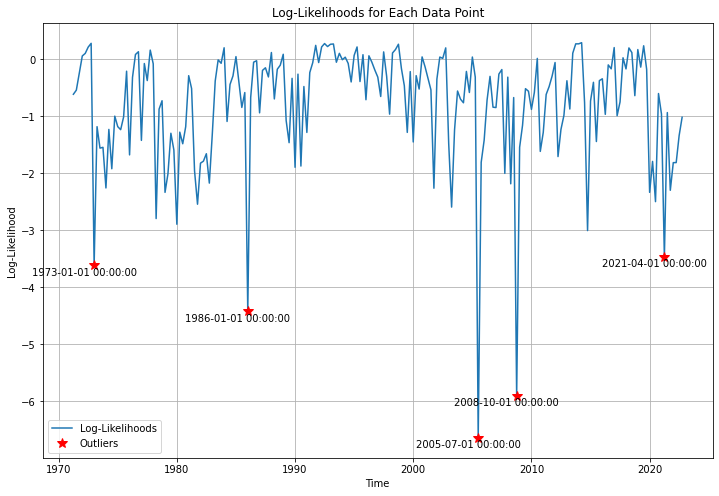

In [59]:
best_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='GARCH',p=2,o=2,q=1,lags=[1],dist='t').fit(disp='off')
log_likelihoods = loglikelihood_t(best_aic.params[-1],best_aic.resid,best_aic.conditional_volatility**2)

# Find the 8 most negative values
outliers = log_likelihoods.nsmallest(5)

plt.figure(figsize=(12, 8))  # Set the figure size
plt.plot(log_likelihoods,label='Log-Likelihoods')
# Adding more details to the plot
plt.title('Log-Likelihoods for Each Data Point')
plt.xlabel('Time')  # Replace 'Time' with the appropriate label for your x-axis
plt.ylabel('Log-Likelihood')
plt.grid(True)
# Plot the outliers with a different color and marker
plt.plot(outliers.index, outliers.values, 'r*', markersize=10, label='Outliers')
for x, y in zip(outliers.index, outliers.values):
    plt.annotate(str(x), (x, y), textcoords="offset points", xytext=(-10,-10), ha='center')

plt.legend()  # Display the legend
plt.show()

In [54]:
outliers

2005-07-01   -6.641900
2008-10-01   -5.905163
1986-01-01   -4.422068
1973-01-01   -3.611859
2021-04-01   -3.469310
Name: cond_vol, dtype: float64

BIC: mean(FC)--EGARCH(1,1)--t_distribution

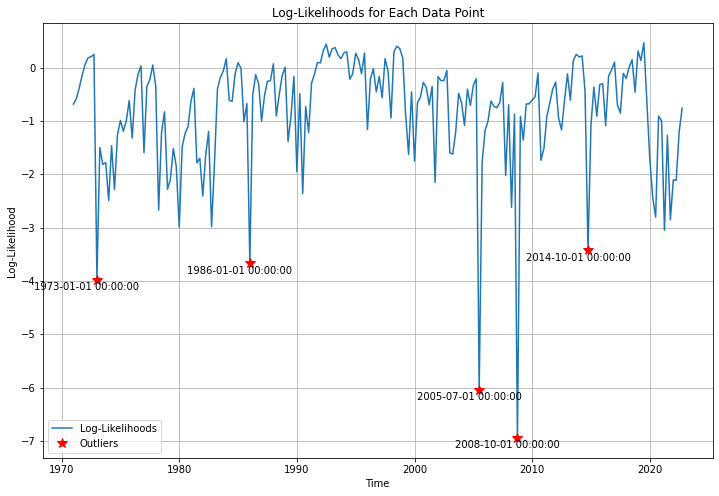

In [60]:
best_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='EGARCH',p=1,o=1,q=1,dist='t').fit(disp='off')
# Adding more details to the plot
log_likelihoods =loglikelihood_t(best_bic.params[-1],best_bic.resid,best_bic.conditional_volatility**2)

# Find the 8 most negative values
outliers = log_likelihoods.nsmallest(5)

plt.figure(figsize=(12, 8))  # Set the figure size
plt.plot(log_likelihoods,label='Log-Likelihoods')
# Adding more details to the plot
plt.title('Log-Likelihoods for Each Data Point')
plt.xlabel('Time')  # Replace 'Time' with the appropriate label for your x-axis
plt.ylabel('Log-Likelihood')
plt.grid(True)
# Plot the outliers with a different color and marker
plt.plot(outliers.index, outliers.values, 'r*', markersize=10, label='Outliers')
for x, y in zip(outliers.index, outliers.values):
    plt.annotate(str(x), (x, y), textcoords="offset points", xytext=(-10,-10), ha='center')

plt.legend()  # Display the legend
plt.show()

In [61]:
outliers

2008-10-01   -6.947165
2005-07-01   -6.046590
1973-01-01   -3.978157
1986-01-01   -3.669273
2014-10-01   -3.429009
Name: cond_vol, dtype: float64

In [38]:
def loglikelihood_t( nu, resids: ArrayLike, sigma2: ArrayLike, individual: bool = True,
    ) -> float | Float64Array:
        r"""Computes the log-likelihood of assuming residuals are have a
        standardized (to have unit variance) Student's t distribution,
        conditional on the variance.

        Parameters
        ----------
        parameters : ndarray
            Shape parameter of the t distribution
        resids  : ndarray
            The residuals to use in the log-likelihood calculation
        sigma2 : ndarray
            Conditional variances of resids
        individual : bool, optional
            Flag indicating whether to return the vector of individual log
            likelihoods (True) or the sum (False)

        Returns
        -------
        ll : float
            The log-likelihood

        Notes
        -----
        The log-likelihood of a single data point x is

        .. math::

            \ln\Gamma\left(\frac{\nu+1}{2}\right)
            -\ln\Gamma\left(\frac{\nu}{2}\right)
            -\frac{1}{2}\ln(\pi\left(\nu-2\right)\sigma^{2})
            -\frac{\nu+1}{2}\ln(1+x^{2}/(\sigma^{2}(\nu-2)))

        where :math:`\Gamma` is the gamma function.
        """
        lls = gammaln((nu + 1) / 2) - gammaln(nu / 2) - log(pi * (nu - 2)) / 2
        lls -= 0.5 * (log(sigma2))
        lls -= ((nu + 1) / 2) * (log(1 + (resids ** 2.0) / (sigma2 * (nu - 2))))

        if individual:
            return lls
        else:
            return sum(lls)

In [15]:
def SPARCH(y,x,mean, p,o,q,lags,vol='GARCH',cov = 'robust'):
    '''
    step 1: run a garch with student t distribution; estimate gaussian mixture parameters from garch residuals
    step 2: run a sparch using garch parameters
    '''
    #run GARCH with student t distribuion as banchmark
    dparams=[0.9,0,1]
    garht = arch_model(y=y,x=x, mean=mean, vol=vol,p=p, o=o,q=q,lags=lags,dist='studentst').fit(disp='off',cov_type=cov)
    params = array(garht.params) +   0.1*array(garht.std_err)*np.random.normal(size=garht.std_err.shape)
    starting_values = np.concatenate( (np.array(params)[:-1],dparams )   )
    constraints = {'type': 'ineq',
                'fun': lambda x: array([ 0.9999 - x[-3] * (x[-2]**2 + x[-1]) - (1 - x[-3]) * (-x[-3] * x[-2] / (1 - x[-3]))**2])} 
    options={'maxiter': 1000,'constraints':constraints}
    sparch = arch_model(y=y,x=x, mean=mean, vol=vol,p=p, o=o,q=q,lags=lags)
    sparch.distribution = MixNormal()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        MixNormalres=sparch.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
    return MixNormalres

In [24]:
#AIC
norm_gjr_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='GARCH',p=2,o=2,q=1,lags=[1],dist='normal').fit(disp='off')
t_gjr_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='GARCH',p=2,o=2,q=1,lags=[1],dist='t').fit(disp='off')
skewt_gjr_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='GARCH',p=2,o=2,q=1,lags=[1],dist='skewt').fit(disp='off')
ged_gjr_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='GARCH',p=2,o=2,q=1,lags=[1],dist='ged').fit(disp='off')
mix_gjr_aic = SPARCH(y= sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', p=2,o=2,q=1,lags=[1],vol='GARCH',cov = 'robust')

norm_egarch_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='EGARCH',p=1,o=1,q=1,lags=[1],dist='normal').fit(disp='off')
t_egarch_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='EGARCH',p=1,o=1,q=1,lags=[1,2],dist='t').fit(disp='off')
skewt_egarch_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='EGARCH',p=1,o=1,q=1,lags=[1,2],dist='skewt').fit(disp='off')
ged_egarch_aic = arch_model(y = sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', vol='EGARCH',p=1,o=1,q=1,lags=[1],dist='ged').fit(disp='off')
mix_egarch_aic = SPARCH(y= sample_data['Inflation'],x=sample_data['Forecasted inflation'],mean='ARX', p=2,o=2,q=1,lags=[1,2],vol='EGARCH',cov = 'robust')



#BIC
norm_gjr_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=2,o=2,q=1,dist='normal').fit(disp='off')
t_gjr_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=1,o=1,q=1,dist='t').fit(disp='off')
skewt_gjr_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=1,o=1,q=1,dist='skewt').fit(disp='off')
ged_gjr_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=1,o=1,q=1,dist='ged').fit(disp='off')
mix_gjr_bic = SPARCH(y = sample_data['Inflation shock'],x=None,mean='Zero', vol='GARCH',p=1,o=1,q=1,cov = 'robust',lags=[])



norm_egarch_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='EGARCH',p=1,o=1,q=1,dist='normal').fit(disp='off')
t_egarch_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='EGARCH',p=1,o=1,q=1,dist='t').fit(disp='off')
skewt_egarch_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='EGARCH',p=1,o=1,q=1,dist='skewt').fit(disp='off')
ged_egarch_bic = arch_model(y = sample_data['Inflation shock'],mean='Zero', vol='EGARCH',p=1,o=1,q=1,dist='ged').fit(disp='off')
mix_egarch_bic = SPARCH(y = sample_data['Inflation shock'],x=None,mean='Zero',p=1,o=1,q=1,vol='EGARCH',cov = 'robust',lags=[])

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

In [26]:
conditional_vol = pd.DataFrame({"norm_gjr_aic":norm_gjr_aic.conditional_volatility,
              "t_gjr_aic":t_gjr_aic.conditional_volatility,
              "skewt_gjr_aic":skewt_gjr_aic.conditional_volatility,
              "ged_gjr_aic":ged_gjr_aic.conditional_volatility,
              "mix_gjr_aic":mix_gjr_aic.conditional_volatility,
              "norm_egarch_aic":norm_egarch_aic.conditional_volatility,
              "t_egarch_aic":t_egarch_aic.conditional_volatility,
              "skewt_egarch_aic":skewt_egarch_aic.conditional_volatility,
              "ged_egarch_aic":ged_egarch_aic.conditional_volatility,
              "mix_egarch_aic":mix_egarch_aic.conditional_volatility,
              "norm_gjr_bic":norm_gjr_bic.conditional_volatility,
              "t_gjr_bic":t_gjr_bic.conditional_volatility,
              "skewt_gjr_bic":skewt_gjr_bic.conditional_volatility,
              "ged_gjr_bic":ged_gjr_bic.conditional_volatility,
              "mix_gjr_bic":mix_gjr_bic.conditional_volatility,
              "norm_egarch_bic":norm_egarch_bic.conditional_volatility,
              "t_egarch_bic":t_egarch_bic.conditional_volatility,
              "skewt_egarch_bic":skewt_egarch_bic.conditional_volatility,
              "ged_egarch_bic":ged_egarch_bic.conditional_volatility,
              "mix_egarch_bic":mix_egarch_bic.conditional_volatility,})

In [29]:
correlation_matrix = conditional_vol.corr()
correlation_matrix.to_excel(r'E:\RA\Geert\corr_conditionalVolatility.xlsx')

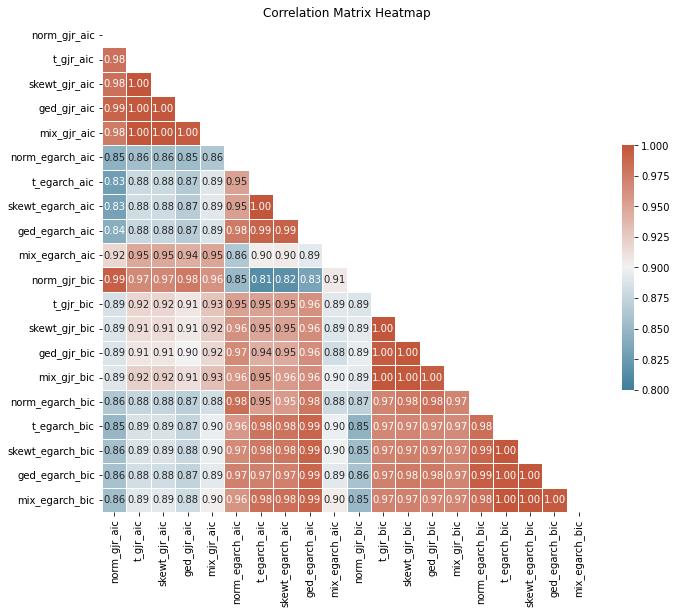

In [37]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, mask=mask, cmap=cmap, annot=True, fmt=".2f", 
            vmax=1, vmin=0.8, center=0.9, square=True, linewidths=.5, 
            cbar_kws={"shrink": .5})

# Set a title
plt.title('Correlation Matrix Heatmap')

# Show the plot
plt.show()